***Cleaning data and creating RFM dataset - input: raw data ("online_retail_II_RAW.csv" -> output: "cleaned_retail_data.csv" +"fm.csv"***

This notebook, cleans the raw dataset ("online_retail_II_RAW.csv") stored in /data.

It also creates the recency, frequency, monetary dataset, explored further in notebook 02

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import urllib.request
import zipfile
import os

URL = "https://archive.ics.uci.edu/static/public/502/online+retail+ii.zip"
os.makedirs("data", exist_ok=True)

print("Downloading dataset...")
urllib.request.urlretrieve(URL, "data/online_retail_ii.zip")

print("Extracting...")
with zipfile.ZipFile("data/online_retail_ii.zip", "r") as f:
    f.extractall("data")

os.remove("data/online_retail_ii.zip")
print("Done! Dataset saved to data/")

Extracting...
Done! Dataset saved to data/


In [3]:
df = pd.read_csv('data/online_retail_II_RAW.csv')
print('Dataframe shape pre processing:', df.shape)
df.head(5)

Dataframe shape pre processing: (1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [4]:
df = df.dropna(subset=['Customer ID'])

df['Invoice'] = pd.to_numeric(df['Invoice'], errors='coerce')
df = df.dropna(subset=['Invoice'])

df = df[df['Quantity']>0]
df = df[df['Price'] >0]

df['Customer ID'] = df['Customer ID'].astype(int)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df['TotalPrice'] = df['Quantity'] * df['Price']


print(f"Cleaned shape: {df.shape}")
print(f"Unique customers: {df['Customer ID'].nunique()}")
print(f"Unique products: {df['StockCode'].nunique()}")
print(f"Date range: {df['InvoiceDate'].min()} → {df['InvoiceDate'].max()}")
df.sample(n=5)

Cleaned shape: (805549, 9)
Unique customers: 5878
Unique products: 4631
Date range: 2009-12-01 07:45:00 → 2011-12-09 12:50:00


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
968950,574701.0,23396,LE JARDIN BOTANIQUE CUSHION COVER,1,2011-11-06 13:54:00,3.75,15426,United Kingdom,3.75
233003,511961.0,21974,SET OF 36 PAISLEY FLOWER DOILIES,12,2010-06-11 13:27:00,1.45,13337,United Kingdom,17.40
259414,514461.0,37449,CERAMIC CAKE STAND + HANGING CAKES,1,2010-07-02 12:41:00,9.95,17841,United Kingdom,9.95
103721,499285.0,84437A,S/6 PINK EASTER DECS IN BOX,7,2010-02-25 19:08:00,0.85,17207,United Kingdom,5.95
603343,542790.0,21742,LARGE ROUND WICKER PLATTER,2,2011-02-01 10:38:00,5.95,16612,United Kingdom,11.90


In [5]:
df.to_csv('data_processed/cleaned_retail_data.csv', index=False)

***RFM dataset creation***

In [6]:
# ── 3. RFM Feature Engineering ────────────────────────────────────────────────
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
# Snapshot date = 1 day after last transaction (standard RFM practice)
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('Customer ID').agg(
    Recency   = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days), #how many days ago since purchase
    Frequency = ('Invoice',     'nunique'),       # number of distinct orders
    Monetary  = ('TotalPrice',  'sum') #Total money spent
).reset_index()

print(rfm.describe())

        Customer ID      Recency    Frequency       Monetary
count   5878.000000  5878.000000  5878.000000    5878.000000
mean   15315.313542   201.331916     6.289384    3018.616737
std     1715.572666   209.338707    13.009406   14737.731040
min    12346.000000     1.000000     1.000000       2.950000
25%    13833.250000    26.000000     1.000000     348.762500
50%    15314.500000    96.000000     3.000000     898.915000
75%    16797.750000   380.000000     7.000000    2307.090000
max    18287.000000   739.000000   398.000000  608821.650000


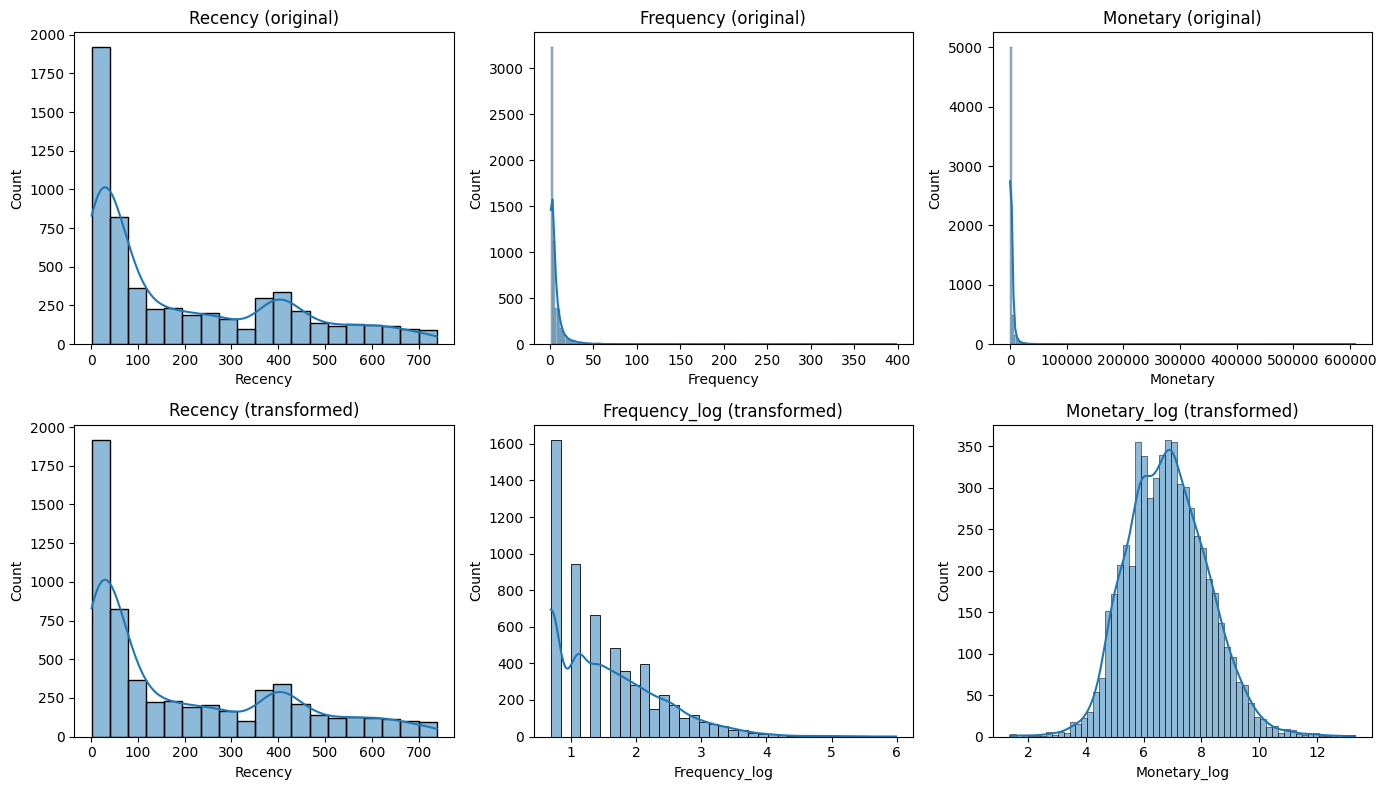

In [7]:
# ── 4. Handle Skewness (important before clustering) ─────────────────────────
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

rfm['Monetary_log']  = np.log1p(rfm['Monetary'])
rfm['Frequency_log'] = np.log1p(rfm['Frequency'])


fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes[0], ['Recency', 'Frequency', 'Monetary']):
    sns.histplot(rfm[col], ax=ax, kde=True)
    ax.set_title(f'{col} (original)')
for ax, col in zip(axes[1], ['Recency', 'Frequency_log', 'Monetary_log']):
    sns.histplot(rfm[col], ax=ax, kde=True)
    ax.set_title(f'{col} (transformed)')
plt.tight_layout()
plt.savefig('plots/rfm_distributions.png', dpi=150)
plt.show()

In [8]:

from sklearn.preprocessing import StandardScaler

features = rfm[['Recency', 'Frequency_log', 'Monetary_log']].copy()
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(features) #Scales values to np.array
rfm['Recency_scaled'] = rfm_scaled[:, 0]
rfm['Frequency_scaled'] = rfm_scaled[:, 1]
rfm['Monetary_scaled'] = rfm_scaled[:, 2]


rfm.to_csv('data_processed/rfm.csv', index=False)